# Parameter estimation and validation of a physics-based 0D steady-state PEMFC performance model

This notebook reproduces the parameter estimation and model validation results described in the paper "A new 0D physics-based model for proton-exchange membrane fuel cell performance simulation" (J. Electrochem. Soc. 2026, 173, 114503), using the `marapendi` physics model (`ExplicitSteadyStateModel`), driven by the **current** `ParameterEstimation` / `CrossValidation` / `UnknownParameter` API (`marapendi.dynamic.simulation.estimation`, `marapendi.estimation.cross_validation`), with `marapendi.estimation.parameter_estimation.Case`/`ParameterEstimation` as the forward-model glue.

This is a **standalone** version of `durasys-data/parameter_estimation_legacy.ipynb`: the experimental data (MEA62, conditions/variations 0, 1, 2, 4, 5, 6, 8, 10, 15) is embedded directly below, so this notebook only depends on the `marapendi` package (no `durasys-data` data files or helper modules). Results are expected to match `durasys-data/results/results_final_estimation_model2_new_perm_lim_cv.csv`.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import marapendi as mrpd
from marapendi.estimation.estimation import SteadyStateModel
from marapendi.estimation.cross_validation import (
    run_cross_validation,
    save_cross_validation_results,
    load_cross_validation_results,
    plot_rmse_vs_complexity,
    plot_cross_validation_curves,
    plot_parameter_vs_complexity,
    get_complexity_levels,
    get_folds_for_complexity,
    rmse_complexity_table,
)

In [2]:
filename = 'final_estimation_model2_new_perm_lim_Affonso_Nobrega_et_al_2026_JES'

## Experimental data (hardcoded, MEA62)

In [3]:
# Operating conditions for the 9 selected variations of MEA62.
variations = [0, 1, 2, 4, 15, 6, 5, 8, 10]  # The new 5 is the 10, the new 9 is the 7
case_variations = pd.DataFrame({'Variation': variations,
                                'Case ID': [k + 1 for k in range(len(variations))]}).set_index('Case ID')
full_case_list = list(case_variations.index)

conditions_data = {
    'Variation':   variations,
    'temperature': [80, 50, 80, 80, 80, 90, 50, 80, 80],
    'pressure-an': [1.5, 2.5, 1.5, 2.5, 2.5, 1.5, 1.5, 1.5, 1.5],
    'pressure-ca': [1.5, 2.5, 1.5, 2.5, 2.3, 1.5, 1.5, 1.5, 1.5],
    'rh-an':       [50, 50, 30, 30, 50, 50, 80, 80, 80],
    'rh-ca':       [50, 50, 30, 30, 30, 50, 80, 80, 80],
    'st-an':       [1.5, 1.5, 1.2, 2.0, 1.5, 1.5, 1.5, 2.0, 1.5],
    'st-ca':       [2.0, 2.0, 2.5, 2.5, 2.0, 2.5, 2.0, 2.5, 1.5],
}
conditions_df = pd.DataFrame(conditions_data).set_index('Variation')

condition_color = {case: f'C{k}' for k, case in enumerate(full_case_list)}
conditions_df.loc[case_variations['Variation']]

,temperature,pressure-an,pressure-ca,rh-an,rh-ca,st-an,st-ca
Variation,,,,,,,
0,80,1.5,1.5,50,50,1.5,2.0
1,50,2.5,2.5,50,50,1.5,2.0
2,80,1.5,1.5,30,30,1.2,2.5
4,80,2.5,2.5,30,30,2.0,2.5
15,80,2.5,2.3,50,30,1.5,2.0
6,90,1.5,1.5,50,50,1.5,2.5
5,50,1.5,1.5,80,80,1.5,2.0
8,80,1.5,1.5,80,80,2.0,2.5
10,80,1.5,1.5,80,80,1.5,1.5


In [4]:
# Polarization curve and HFR data, averaged over ascending/descending sweeps.
_exp_data_csv = """case,current_A_cm2,voltage_V,hfr_ohm_cm2
1,0,0.911451,
1,0.08,0.819964,0.0413076
1,0.2,0.783851,
1,0.4,0.746728,0.0397381
1,0.6,0.7192,
1,0.8,0.691927,
1,1,0.666024,0.0369162
1,1.2,0.637758,
1,1.4,0.609555,
1,1.56,0.587704,
2,0,0.946503,
2,0.08,0.861721,0.0386086
2,0.2,0.823163,
2,0.4,0.782723,0.0377255
2,0.6,0.750069,
2,0.8,0.719233,
2,1,0.687873,0.0364815
2,1.2,0.656312,
2,1.4,0.626726,
2,1.56,0.605712,
2,1.59,0.599881,
3,0,0.919656,
3,0.08,0.814908,0.04987
3,0.2,0.772305,
3,0.4,0.730443,0.0554072
3,0.6,0.69555,
3,0.8,0.664588,
3,1,0.636433,0.0528002
3,1.2,0.610458,
3,1.4,0.583257,
3,1.56,0.549974,
3,1.8,0.494066,
3,1.96,0.436816,
4,0,0.929941,
4,0.08,0.851711,0.0368974
4,0.2,0.816085,
4,0.4,0.785446,0.0374853
4,0.6,0.760909,
4,0.8,0.740034,
4,1,0.720167,0.0365731
4,1.2,0.701043,
4,1.4,0.679064,
4,1.56,0.657917,
4,1.8,0.619024,
4,2,0.578545,
5,0,0.927345,
5,0.08,0.843686,0.0363732
5,0.2,0.807182,
5,0.4,0.774042,0.037437
5,0.6,0.75205,
5,0.8,0.729708,
5,1,0.707576,0.0338028
5,1.2,0.684814,
5,1.4,0.661233,
5,1.56,0.642694,
5,1.79,0.599711,
6,0,0.922887,
6,0.08,0.810585,0.0478001
6,0.2,0.774263,
6,0.4,0.737869,0.0453726
6,0.6,0.70696,
6,0.8,0.678401,
6,1,0.651822,0.0446186
6,1.2,0.626913,
6,1.4,0.596979,
6,1.56,0.566364,
7,0,0.929048,
7,0.08,0.829254,0.0376741
7,0.2,0.790205,
7,0.4,0.752194,0.0370008
7,0.6,0.722174,
7,0.8,0.693328,
7,1,0.664069,0.0362274
7,1.2,0.635142,
7,1.4,0.606177,
7,1.56,0.583332,
8,0,0.919067,
8,0.08,0.826517,0.0333321
8,0.2,0.791053,
8,0.4,0.757887,0.0318667
8,0.6,0.733209,
8,0.8,0.711132,
8,1,0.689397,0.0322763
8,1.16,0.672052,
8,1.4,0.640206,
8,1.56,0.611004,
8,1.6,0.600006,
9,0,0.91687,
9,0.08,0.823573,0.0330154
9,0.2,0.782671,
9,0.4,0.748927,0.032455
9,0.6,0.722018,
9,0.8,0.695022,
9,1,0.66496,0.0322796
9,1.2,0.631988,
9,1.4,0.596083,
9,1.56,0.565461,
"""

_exp_data_df = pd.read_csv(pd.io.common.StringIO(_exp_data_csv))

exp_current = {}
exp_voltage = {}
exp_hfr = {}
for case, group in _exp_data_df.groupby('case'):
    exp_current[case] = group['current_A_cm2'].to_numpy()
    exp_voltage[case] = group['voltage_V'].to_numpy()
    exp_hfr[case] = group['hfr_ohm_cm2'].to_numpy()

# Ratio of polarization-curve points to HFR points across the full MEA62
# dataset (used to balance the contribution of voltage and HFR residuals).
hfr_weight_factor = 5.2

case_exp_data = {}
for case in full_case_list:
    case_exp_data[case] = np.concatenate([
        exp_voltage[case],
        np.nan_to_num(exp_hfr[case], nan=0.) * hfr_weight_factor])


def get_cases_exp_data(case_list):
    return np.concatenate([case_exp_data[case] for case in case_list])

## Fuel-cell model definition

`create_cell` maps the 38 unknown parameters + fixed `initial_parameters` onto `marapendi` component dataclasses (`Cell`, `PFSA`, `PtCCatalystLayer`, `GasDiffusionLayer`, `FlowChannel`, `PFSAIonomer`, `ElectrochemicalReaction`).

In [5]:
def create_cell(params):
    class NewPermModel(mrpd.HydrogenPermeationModel):
        def permeation_flux(self, membrane_thickness, partial_pressure_h2,
                            temperature, pressure_difference, water_vol_fraction):
            return self.permeability_correction_factor * (
                15.7e-9 * np.exp(-20280 / 8.3415 / temperature) +
                water_vol_fraction * 45e-9 * np.exp(-18930 / 8.3145 / temperature)
            ) / 1000 * 100 / 1e5 * partial_pressure_h2 / membrane_thickness

    membrane = mrpd.PFSA(
        ionomer=mrpd.PFSAIonomer(
            equivalent_weight=params['memb-equiv-weight'],
            dry_density=2000.,
            conductivity_exp=params['memb-cond-exp'],
            conductivity_activation_energy=params['memb-E-act-cond'],
            conductivity_correction=params['memb-cond-correction'],
            reference_water_diffusivity=params['memb-water-diff'],
            reference_water_absorption_coefficient=params['memb-abs-constant'],
            water_diffusivity_activation_energy=params['E-act-memb-diff'],
            water_absorption_activation_energy=params['E-act-memb-abs'],
        ),
        dry_thickness=params['memb-thickness'],
        h2_permeation_model=NewPermModel(permeability_correction_factor=params['ix-corr']),
    )

    orr_kinetics = mrpd.ElectrochemicalReaction(
        reference_exchange_current_density=params['i0-c'],
        reaction_order=params['gamma-c'],
        activation_energy=params['E-act-ca'],
        reference_activity=1.01325e5,
        reference_temperature=353.15,
        number_of_electrons=1,
        charge_transfer_coeff=params['alpha-c'],
    )

    liq_model = mrpd.DarcyTransportModel(J_function_exponent=params['wet-transition'])

    gdl = {
        side: mrpd.GasDiffusionLayer(
            thickness=params['gdl-thickness'],
            contact_angle=params['gdl-theta'],
            effective_gas_diffusion_ratio=params['gdl-eff-diff-ratio'],
            absolute_permeability=params['gdl-abs-perm'],
            porosity=params['gdl-porosity'],
            thermal_conductivity=params['gdl-thermal-cond'],
            two_phase_transport_model=liq_model,
            transport_resistance_model=mrpd.PorousGasDiffusionModel(
                water_saturation_exponent=params['n_s']),
        ) for side in ['ca', 'an']
    }

    ch = {
        side: mrpd.FlowChannel(
            height=params['ch-height'], width=1e-3, n_parallel=1, length=21 * 50e-3,
            reactant='o2' if side == 'ca' else 'h2',
            transport_resistance_model=mrpd.ChannelGasResistanceModel(
                sherwood=params['Sh'], B_ch=params['B_ch']),
        ) for side in ['an', 'ca']
    }

    ionomer = mrpd.PFSAIonomer(
        conductivity_correction=params['ionomer-cond-corr'],
        conductivity_exp=params['ionomer-cond-exp'],
        conductivity_activation_energy=params['ionomer-E-act-cond'],
    )

    ca_cl = mrpd.PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=params['pt-loading'], ionomer=ionomer,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'],
        ionomer_k1=params['ionomer-k1'], ionomer_k2=params['ionomer-k2'],
        ionomer_k3=params['ionomer-k3'],
        pore_diameter=params['cl-pore-diameter'], omega_PtO=0,
        carbon_agglomerate_radius=params['radius-carbon'],
        thickness=params['pt-loading'] * 2.8e-6 / 0.1e-2,
        absolute_permeability=params['cl-abs-perm'], contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'], reaction=orr_kinetics,
        two_phase_transport_model=liq_model,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )

    an_cl = mrpd.PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=1e-3,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'], ionomer=ionomer,
        pore_diameter=params['cl-pore-diameter'],
        carbon_agglomerate_radius=params['radius-carbon'],
        thickness=2.8e-6, absolute_permeability=params['cl-abs-perm'],
        contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'],
        two_phase_transport_model=liq_model,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )

    return mrpd.FuelCell(
        electrical_resistance=params['elec-resistance'],
        area=25e-4,
        ca=mrpd.FuelCellSide(
            cl=ca_cl, gdl=gdl['ca'], has_gdl=True, has_mpl=False, ch=ch['ca'],
            thermal_contact_resistance=params['tcr'],
        ),
        an=mrpd.FuelCellSide(
            cl=an_cl, gdl=gdl['an'], has_gdl=True, has_mpl=False, ch=ch['an'],
            thermal_contact_resistance=params['tcr'],
        ),
        membrane=membrane,
    )

In [6]:
CELL_AREA = 25e-4  # m²
FARADAY = 96485.0  # C/mol


def build_cases(exp_current, conditions_df, full_case_list, case_variations):
    """Build a per-condition dict with CellConditions and experimental data."""
    result = {}
    for case in full_case_list:
        row = conditions_df.loc[case_variations.loc[case, 'Variation']]

        T = row['temperature'] + 273.15
        p_ca = 1e5 * row['pressure-ca']
        p_an = 1e5 * row['pressure-an']
        i = 1e4 * exp_current[case] + 1  # A/m²

        st_ca = np.maximum(row['st-ca'], 2 / 24.5 / 3600 * 0.21 / (i * CELL_AREA / 4 / FARADAY))
        st_an = np.maximum(row['st-an'], 2 / 24.5 / 3600 * 1.0 / (i * CELL_AREA / 2 / FARADAY))

        cond = mrpd.CellConditions(
            current_density=i,
            cell_temperature=T,
            ca=mrpd.SideConditions(
                inlet_temperature=T,
                outlet_pressure=p_ca,
                inlet_relative_humidity=row['rh-ca'] / 100.,
                dry_o2_mole_fraction=0.21,
                stoichiometry=st_ca,
            ),
            an=mrpd.SideConditions(
                inlet_temperature=T,
                outlet_pressure=p_an,
                inlet_relative_humidity=row['rh-an'] / 100.,
                dry_h2_mole_fraction=1.0,
                stoichiometry=st_an,
            ),
        )
        result[case] = {
            'conditions': cond,
            'exp_data': {'voltage': exp_voltage[case], 'hfr': exp_hfr[case]},
        }
    return result

In [ ]:
initial_parameters = {
    'i0-c': 2.54e-4,
    'gamma-c': 0.54,
    'alpha-c': 1.,
    'radius-carbon': 25e-9,
    'ionomer-E-act-cond': 15e6,
    'n_s': 2,
    'memb-E-act-cond': 15e6,
    'ionomer-cond-corr': 1,
    'ionomer-cond-exp': 1.5,
    'E-act-ca': 67e6,
    'ionomer-k1': 8.5,
    'ionomer-k2': 5.4,
    'ionomer-k3': 5.4,
    'alpha-w': 1,
    'gdl-porosity': 0.6,
    'elec-resistance': 33e-7,
    'tcr': 4.4e-4,
    'pt-wt-percent': 0.4,
    'Sh': 3.6, 'B_ch': 1., 'ch-height': 1e-3,

    'gdl-thickness': 150e-6,
    'gdl-theta': 120.,
    'gdl-eff-diff-ratio': 0.3,
    'gdl-thermal-cond': 0.5,  # Sigracet at 10 MPa Ozden et al. (2019)
    'gdl-abs-perm': 1e-12,
    'cl-abs-perm': 1e-13,
    'ix-corr': 1.,

    'wet-transition': 0.4,
    'pt-loading': .3e-2,
    'ic-ratio': 1.4,
    'ecsa': 60e3,
    'memb-thickness': 12e-6,
    'memb-equiv-weight': 1100.,
    'memb-cond-correction': 1.0,
    'memb-water-diff': 2e-10,
    'memb-abs-constant': 1e-5,
    'memb-cond-exp': 1.5,
    'E-act-memb-diff': 20e6,
    'E-act-memb-abs': 20e6,

    'cl-theta': 97.,
    'cl-thermal-cond': 0.22,
    'cl-pore-diameter': 40e-9,

    'eod-parallel': False,
    'sorption-driving-force': False
}

In [8]:
def UnknownParameter(name, label, unit, lower, upper, log_scale=False):
    """Return a parameter tuple in the format expected by SteadyStateModel.set_unknown_params."""
    return (name, (lower, upper), not log_scale, label)


unknown_parameters = [
    # ORR kinetics - 4 params
    UnknownParameter('i0-c', r'$i_{0,ca}$', 'A/cm$^2$ Pt', 1e-5, 1e-2, log_scale=True),
    UnknownParameter('gamma-c', r'$\gamma_{ca}$', 'n.d.', 0.5, 1., log_scale=False),
    UnknownParameter('alpha-c', r'$\alpha_{ca}$', 'n.d.', 0.5, 1., log_scale=False),
    UnknownParameter('E-act-ca', '$E_{act,ca}$', 'kJ/mol', 30e6, 80e6, log_scale=False),

    # CL properties - 7 params
    UnknownParameter('pt-loading', r'$L_{\text{Pt},ca}$', 'mg/cm²', 0.2e-2, 0.5e-2, log_scale=False),
    UnknownParameter('ecsa', 'ECSA', 'm²/g', 40e3, 90e3, log_scale=False),
    UnknownParameter('ic-ratio', 'IC$_{ca}$', 'n.d.', 0.5, 1.4, log_scale=False),
    UnknownParameter('radius-carbon', '$r_C$', 'nm', 10e-9, 40e-9, log_scale=False),
    UnknownParameter('cl-abs-perm', r'$K^{abs}_{\text{CL}}$', 'e-12 m²', 1e-14, 1e-12, log_scale=True),
    UnknownParameter('cl-pore-diameter', r'$d_{p,\text{CL}}$', 'nm', 10e-9, 70e-9, log_scale=False),
    UnknownParameter('cl-theta', r'$\theta_{\text{CL}}$', 'deg', 92, 110, log_scale=False),

    # Ionomer properties - 6 params
    UnknownParameter('ionomer-k1', '$k_1$', 'n.d.', 2, 10, log_scale=False),
    UnknownParameter('ionomer-k2', '$k_2$', 'n.d.', 2, 10, log_scale=False),
    UnknownParameter('ionomer-k3', '$k_3$', 'n.d.', 2, 10, log_scale=False),
    UnknownParameter('ionomer-cond-corr', r'$\xi_{\sigma}^{ion}$', 'n.d.', 0.1, 50, log_scale=True),
    UnknownParameter('ionomer-cond-exp', r'$n_{\sigma}^{ion}$', 'n.d.', 1, 2, log_scale=False),
    UnknownParameter('ionomer-E-act-cond', r'$E^{ion}_{act,\sigma}$', 'kJ/mol', 5e6, 30e6, log_scale=False),

    # Membrane properties - 10 params
    UnknownParameter('ix-corr', r'$\xi_x$', 'n.d.', 0.5, 2, log_scale=False),
    UnknownParameter('memb-cond-correction', r'$\xi_{\sigma}^{mb}$', 'n.d.', 0.1, 50, log_scale=True),
    UnknownParameter('memb-cond-exp', r'$n_{\sigma}^{mb}$', 'n.d.', 1, 2, log_scale=False),
    UnknownParameter('memb-E-act-cond', r'$E^{mb}_{act,\sigma}$', 'kJ/mol', 5e6, 30e6, log_scale=False),
    UnknownParameter('memb-thickness', r'$\delta_{mb}$', 'μm', 8e-6, 15e-6, log_scale=False),
    UnknownParameter('memb-equiv-weight', 'EW', 'g/mol', 700., 1100., log_scale=False),
    UnknownParameter('memb-water-diff', r'$D_{\lambda}$', '10$^{-10}$ m$^2$/s', 1e-10, 10e-10, log_scale=False),
    UnknownParameter('memb-abs-constant', '$k_{abs}$', 'm/s', 1e-6, 1e-4, log_scale=True),
    UnknownParameter('E-act-memb-diff', r'$E^{mb}_{act,D_\lambda}$', 'kJ/mol', 15e6, 30e6, log_scale=False),
    UnknownParameter('E-act-memb-abs', r'$E^{mb}_{act,abs}$', 'kJ/mol', 15e6, 30e6, log_scale=False),

    # GDL properties - 5 params
    UnknownParameter('gdl-thickness', r'$\delta_{\text{GDL}}$', 'μm', 100e-6, 200e-6, log_scale=False),
    UnknownParameter('gdl-eff-diff-ratio', r'$D_{\text{GDL}}^{\mathit{eff}}/D$', 'n.d.', 0.05, 0.5, log_scale=False),
    UnknownParameter('gdl-abs-perm', r'$K^{abs}_{\text{GDL}}$', 'e-12 m²', 1e-13, 1e-11, log_scale=True),
    UnknownParameter('gdl-thermal-cond', r'$k_{\text{GDL}}$', 'W/mK', 0.05, 2, log_scale=True),
    UnknownParameter('gdl-theta', r'$\theta_{\text{GDL}}$', 'deg', 100, 150, log_scale=False),

    # Other - 6 params
    UnknownParameter('tcr', 'TCR', '10$^{-4}$ Kcm$^2$/W', 0, 10e-4, log_scale=False),
    UnknownParameter('elec-resistance', '$r_{elec}$', 'mΩ·cm', 10e-7, 50e-7, log_scale=False),
    UnknownParameter('Sh', '$Sh$', 'n.d.', 0.01, 10, log_scale=True),
    UnknownParameter('B_ch', r'$\xi_{\text{CH}}$', 'n.d.', 0, 5, log_scale=False),
    UnknownParameter('wet-transition', '$n_{J}$', 'n.d.', 0.1, 3, log_scale=False),
    UnknownParameter('n_s', '$n_s$', 'n.d.', 1.5, 3, log_scale=False),
]

In [9]:
parameter_units = {
    'i0-c': ('\SI{}{\ampere\per\centi\meter_{\ce{Pt}}\squared}', 1, 'A/cm$^2$ Pt'),
    'gamma-c': ('-', 1, 'n.d.'),
    'alpha-c': ('-', 1, 'n.d.'),
    'ecsa': ('\si{\square\meter\per\gram}', 1e3, 'm²/g'),
    'radius-carbon': ('\si{\nano\meter}', 1e-9, 'nm'),
    'ionomer-E-act-cond': ('\si{\kilo\joule\per\mole}', 1e6, 'kJ/mol'),
    'n_s': ('-', 1, 'n.d.'),
    'memb-E-act-cond': ('\si{\kilo\joule\per\mole}', 1e6, 'kJ/mol'),
    'ionomer-cond-corr': ('-', 1, 'n.d.'),
    'ionomer-cond-exp': ('-', 1, 'n.d.'),
    'E-act-ca': ('\si{\kilo\joule\per\mole}', 1e6, 'kJ/mol'),
    'ionomer-k1': ('-', 1, 'n.d.'),
    'ionomer-k2': ('-', 1, 'n.d.'),
    'ionomer-k3': ('-', 1, 'n.d.'),
    'alpha-w': ('-', 1, 'n.d.'),
    'gdl-porosity': ('-', 1, 'n.d.'),
    'elec-resistance': ('\si{\milli\ohm\square\centi\meter}', 1e-7, 'mΩ·cm'),
    'tcr': ('\SI{e-4}{\kelvin\square\centi\meter\per\watt}', 1e-4, '10$^{-4}$ Kcm$^2$/W'),
    'pt-wt-percent': ('-', 1, 'n.d.'),
    'Sh': ('-', 1, 'n.d.'),
    'B_ch': ('-', 1, 'n.d.'),
    'ch-height': ('\si{\milli\meter}', 1e-3, 'mm'),
    'gdl-eff-diff-ratio': ('-', 1, 'n.d.'),
    'gdl-thickness': ('\si{\micro\meter}', 1e-6, 'μm'),
    'gdl-theta': ('-', 1, 'deg'),
    'cl-theta': ('-', 1, 'deg'),
    'gdl-thermal-cond': ('\si{\watt\per\meter\per\kelvin}', 1, 'W/mK'),
    'gdl-abs-perm': ('\SI{e-12}{\square\meter}', 1e-12, 'e-12 m²'),
    'ix-corr': ('-', 1, 'n.d.'),
    'wet-transition': ('-', 1, 'n.d.'),
    'pt-loading': ('\si{\milli\gram\per\square\centi\meter}', 1e-2, 'mg/cm²'),
    'ic-ratio': ('-', 1, 'n.d.'),
    'memb-thickness': ('\si{\micro\meter}', 1e-6, 'μm'),
    'memb-equiv-weight': ('\SI{}{\gram\mole}', 1, 'g/mol'),
    'memb-water-diff': ('\SI{e-10}{\square\meter\per\second}', 1e-10, '10$^{-10}$ m$^2$/s'),
    'memb-abs-constant': ('\SI{}{\meter\per\second}', 1, 'm/s'),
    'memb-cond-correction': ('-', 1, 'n.d.'),
    'memb-cond-exp': ('-', 1, 'n.d.'),
    'E-act-memb-diff': ('\si{\kilo\joule\per\mole}', 1e6, 'kJ/mol'),
    'E-act-memb-abs': ('\si{\kilo\joule\per\mole}', 1e6, 'kJ/mol'),
    'cl-thermal-cond': ('\si{\watt\per\meter\per\kelvin}', 1, 'W/mK'),
    'cl-pore-diameter': ('\si{\nano\meter}', 1e-9, 'nm'),
    'cl-abs-perm': ('\SI{e-12}{\square\meter}', 1e-12, 'e-12 m²'),
}

## Model and unknown parameters

Wire `create_cell` / `ExplicitSteadyStateModel` to `ParameterEstimation` via the `marapendi.estimation.parameter_estimation.Case`/`ParameterEstimation` forward-model glue. The 38 unknown parameters and their bounds (Table II of the paper) are defined as `UnknownParameter` objects above.

In [10]:
cases = build_cases(exp_current, conditions_df, full_case_list, case_variations)

# Single shared model instance — reused across all evaluations.
_esm = mrpd.ExplicitSteadyStateModel()


def solve_case(cell, cond):
    """Evaluate ExplicitSteadyStateModel and return the solved CellState."""
    state = _esm.set_initial_conditions(cell, cond)
    return _esm.solve(cell, cond, state)


def extract_outputs(cell, cond, exp_data):
    """Return concatenated [voltages, weighted_hfr] for one case."""
    state = solve_case(cell, cond)
    hfr_mask = np.isfinite(exp_data['hfr'])
    hfr_sim = (
        _esm.voltage_model.high_frequency_resistance(cell, state)
        * 1e4 * hfr_mask * hfr_weight_factor
    )
    return np.concatenate([state.cell_voltage, hfr_sim])


def build_model(case_list, base_params=None):
    """Return a SteadyStateModel for the given list of cases.

    Used both to build the global model (``pe``) and as the
    ``build_model`` callback required by ``run_cross_validation``.
    """
    base_params = (base_params or initial_parameters).copy()

    def model_fn(params):
        cell = create_cell(params)
        return np.concatenate([
            extract_outputs(cell, cases[c]['conditions'], cases[c]['exp_data'])
            for c in case_list
        ])

    m = SteadyStateModel(h=model_fn, p=base_params)
    m.set_unknown_params(unknown_parameters)
    return m


def model_builder(params, case):
    """Return a FuelCell built from *params* (used by CV plot functions)."""
    return create_cell(params)


def simulate_callback(case, cell):
    """Simulate one case and return (x_sim, y_sim, x_exp, y_exp) in A/cm²."""
    state = solve_case(cell, cases[case]['conditions'])
    x_sim = np.atleast_1d(cases[case]['conditions'].current_density) * 1e-4
    return x_sim, state.cell_voltage, exp_current[case], exp_voltage[case]


# Global estimation model (all 9 conditions).
pe = build_model(full_case_list, initial_parameters.copy())

## Initial model vs experimental data

Sanity check before running sensitivity analysis / cross-validation.

Single full evaluation (9 conditions): 0.005 s


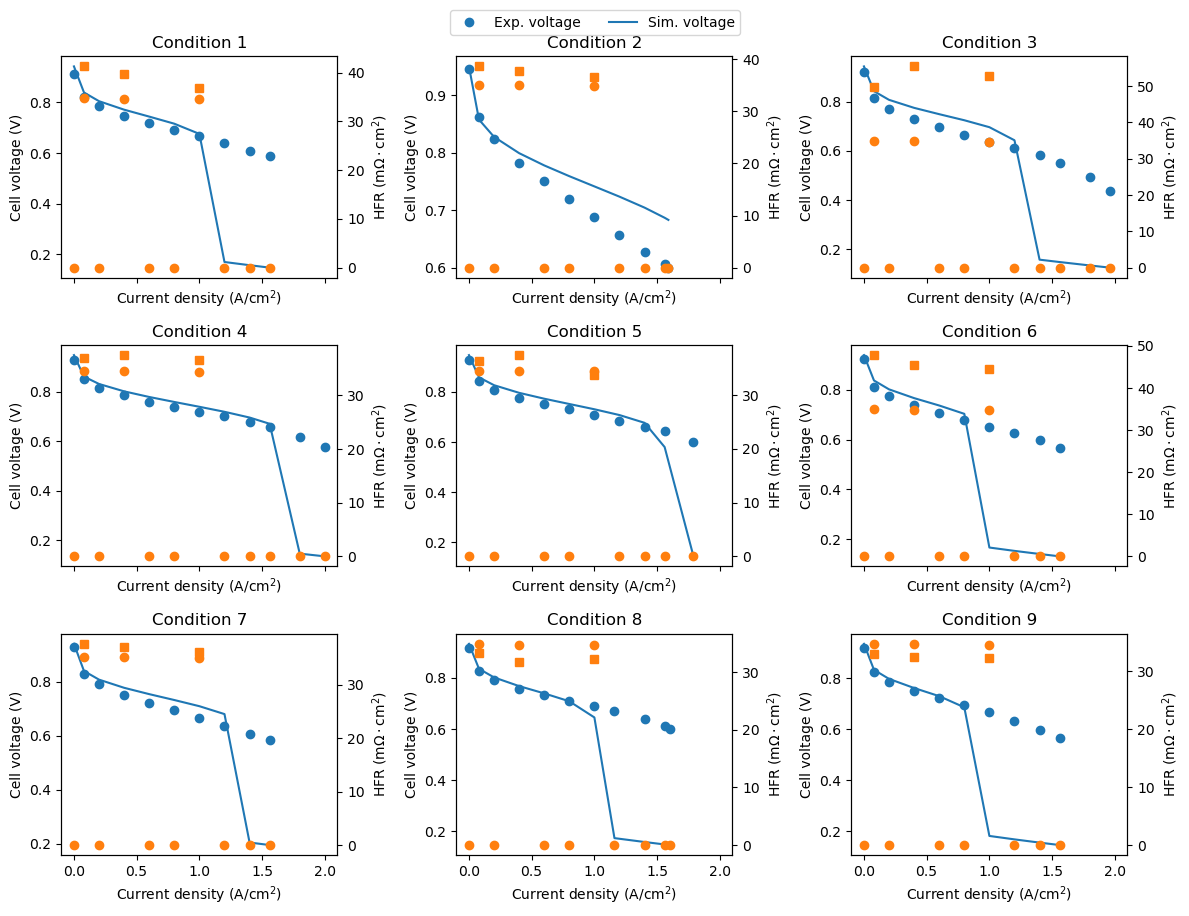

In [11]:
y_exp_init = get_cases_exp_data(full_case_list)
t0 = time.time()
y_sim_init = pe.solve(0)[2]   # SteadyStateModel.solve(t) -> (0, 0, y)
print(f'Single full evaluation (9 conditions): {time.time() - t0:.3f} s')

n_cols = 3
n_rows = int(np.ceil(len(full_case_list) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True)
axes = np.atleast_1d(axes).ravel()

offset = 0
for ax, case in zip(axes, full_case_list):
    n = len(exp_current[case])
    chunk_sim = y_sim_init[offset:offset + 2 * n]
    offset += 2 * n

    v_sim = chunk_sim[:n]
    hfr_sim = chunk_sim[n:] / hfr_weight_factor   # remove weighting for display

    ax.plot(exp_current[case], exp_voltage[case], 'o', color='C0', label='Exp. voltage')
    ax.plot(exp_current[case], v_sim, '-', color='C0', label='Sim. voltage')
    ax.set_title(f'Condition {case}')
    ax.set_xlabel('Current density (A/cm$^2$)')
    ax.set_ylabel('Cell voltage (V)')

    ax_hfr = ax.twinx()
    hfr_mask = np.isfinite(exp_hfr[case])
    ax_hfr.plot(exp_current[case][hfr_mask], 1e3 * np.asarray(exp_hfr[case])[hfr_mask],
                's', color='C1', label='Exp. HFR')
    ax_hfr.plot(exp_current[case], 1e3 * hfr_sim, 'o', color='C1', label='Sim. HFR')
    ax_hfr.set_ylabel(r'HFR (m$\Omega \cdot$cm$^2$)')

for ax in axes[len(full_case_list):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

## Global sensitivity analysis

In [ ]:
(
    cosPhi_med_ij, norm_s_i, S_med, S_std,
    S_med_i, S_std_i, S_n, n_valid, p_valid,
) = pe.compute_global_sensitivity(
    t=0,
    m=12,
    check_samples=True,
    y_exp=get_cases_exp_data(full_case_list),
    rmse_limit=0.05,
    filename_to_save=f'sensitivity_results_{filename}',
)

ValueError: einstein sum subscripts string contains too many subscripts for operand 0

In [ ]:
# Load pre-computed results instead of re-running:
# pe.load_global_sensitivity_results(f'sensitivity_results_{filename}.npz')

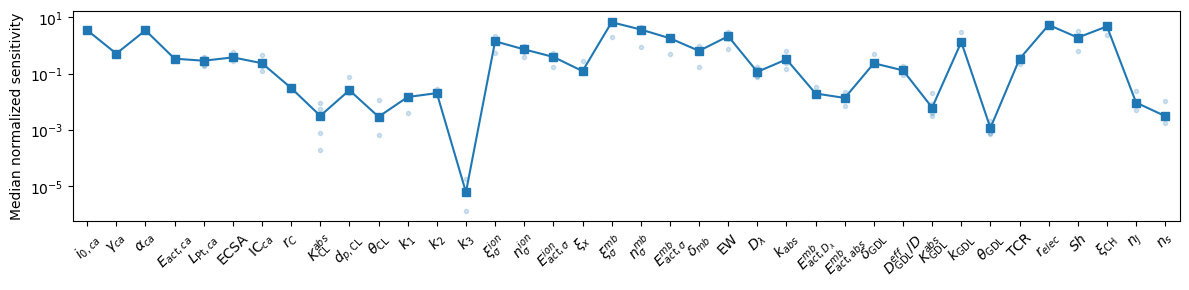

In [ ]:
fig, ax = pe.plot_global_sensitivity(figsize=(12, 3))
#fig.savefig(f'figures/global_sensitivity_{filename}.png', dpi=300, bbox_inches='tight')

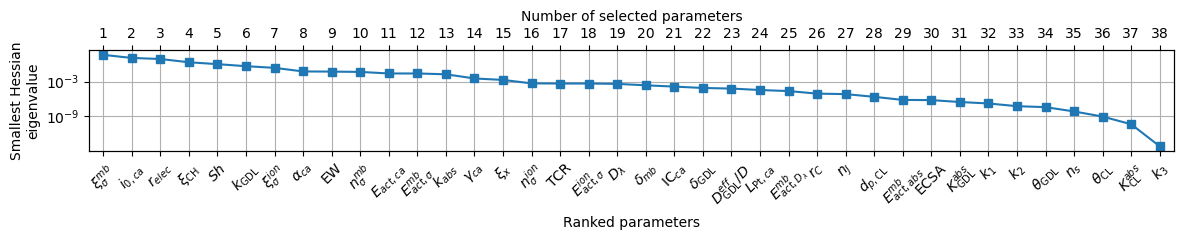

In [ ]:
P, num_parameters, fig, ax, ax2 = pe.plot_parameter_ranking()
# fig.savefig(f'figures/parameter_ranking_{filename}.png', dpi=300, bbox_inches='tight')

## Leave-one-out cross-validation

Resumes from `results/results_{filename}_cv.csv` and checkpoints after each complexity level. A previous run's results are already included alongside this notebook (`results/results_final_estimation_model2_new_perm_lim_Affonso_Nobrega_et_al_2026_JES_cv.csv`).

In [ ]:
def checkpoint_callback(cv_results):
    save_cross_validation_results(cv_results, filename)

cv_results = run_cross_validation(
    base_model=pe,
    parameter_indices=P,
    case_list=full_case_list,
    build_model=build_model,
    get_exp_data=get_cases_exp_data,
    checkpoint_callback=checkpoint_callback,
    estimate_kwargs=dict(
        t=0,
        print_iterations=True,
        popsize=10,
        ftol=1e-5,
        penalty_threshold=0,
        rtol=0.1,
        maxiter=120,
    ),
)


Running CV for 1 parameters
differential_evolution step 1: f(x)= 0.001253388246989203
------------------------------
RMSE : 35.4 mV
memb-cond-correction (0.1, 50) 4.23e+01
------------------------------
differential_evolution step 2: f(x)= 0.001253388246989203
------------------------------
RMSE : 35.4 mV
memb-cond-correction (0.1, 50) 4.23e+01
------------------------------
differential_evolution step 3: f(x)= 0.001253388246989203
------------------------------
RMSE : 35.4 mV
memb-cond-correction (0.1, 50) 4.23e+01
------------------------------
differential_evolution step 4: f(x)= 0.0012529763731798421
------------------------------
RMSE : 35.4 mV
memb-cond-correction (0.1, 50) 4.40e+01
------------------------------
Polishing solution with 'L-BFGS-B'
differential_evolution step 1: f(x)= 0.001194663363812821
------------------------------
RMSE : 34.6 mV
memb-cond-correction (0.1, 50) 4.23e+01
------------------------------
differential_evolution step 2: f(x)= 0.001194663363812821
--

KeyboardInterrupt: 

### RMSE vs complexity

In [ ]:
fig, ax, rmse_df, optimal_n = plot_rmse_vs_complexity(
    cv_results=cv_results,
    case_list=full_case_list,
    parameter_indices=P,
    base_model=pe,
    model_builder=model_builder,
    simulate_callback=simulate_callback,
    ylabel='RMSE (mV)',
    quantity_multiplier=1000,
    use_median=True,
    figsize=(12, 4),
    save_path=f'figures/rmse_vs_complexity_{filename}.png',
)
print(f'Optimal number of parameters: {optimal_n}')

### Cross-validation polarisation curves

In [ ]:
n_selected = optimal_n  # or set manually, e.g. 12

case_titles = {
    case: (
        f'Condition {k+1}\n'
        rf'$T_{{cell}}$: {conditions_df.loc[case_variations.loc[case, "Variation"], "temperature"]:.0f} °C\n'
        rf'RH$_{{ca/an}}$: '
        f'{conditions_df.loc[case_variations.loc[case, "Variation"], "rh-ca"]:.0f}/'
        f'{conditions_df.loc[case_variations.loc[case, "Variation"], "rh-an"]:.0f} %\n'
        rf'$p_{{ca/an}}$: '
        f'{conditions_df.loc[case_variations.loc[case, "Variation"], "pressure-ca"]:.1f}/'
        f'{conditions_df.loc[case_variations.loc[case, "Variation"], "pressure-an"]:.1f} bar'
    )
    for k, case in enumerate(full_case_list)
}

fig, ax, rmse_list, maxerr_list, rmse_str, maxerr_str = plot_cross_validation_curves(
    n_parameters=n_selected,
    cv_results=cv_results,
    case_list=full_case_list,
    case_table=case_titles,
    condition_color=condition_color,
    simulate_callback=simulate_callback,
    model_builder=model_builder,
    quantity_name='Cell voltage',
    quantity_symbol=r'$V_{cell}$',
    quantity_unit='V',
    uncertainty=0.1,
    save_path=f'figures/cv_curves_{filename}_{n_selected}.png',
)
print(rmse_str)
print(maxerr_str)

### Parameter evolution vs complexity

In [ ]:
fig, axes, mean_vals, lower_ci, upper_ci = plot_parameter_vs_complexity(
    cv_results=cv_results,
    parameter_indices=P,
    base_model=pe,
    parameter_units=parameter_units,
    condition_color=condition_color,
    initial_parameters=initial_parameters,
    plot_ci=False,
    n_cols=5,
    figsize=(14, 12),
    save_path=f'figures/parameter_vs_complexity_{filename}.png',
)

### Computational time

In [ ]:
complexity_levels = get_complexity_levels(cv_results)

fig, ax = plt.subplots(figsize=(5, 3))
t_avg = np.zeros(len(complexity_levels))
handles = []

for k, case in enumerate(full_case_list):
    t_est = np.array([
        get_folds_for_complexity(cv_results, n)[k]['elapsed_time']
        for n in complexity_levels
    ])
    t_avg += t_est / len(full_case_list)
    l, = ax.semilogy(complexity_levels, t_est, 's', color=condition_color[case],
                     alpha=1, markersize=5)
    handles.append(l)

ax.plot(complexity_levels, t_avg, 'dimgray', linewidth=2)
ax.set_xlabel('Number of selected parameters')
ax.set_ylabel('Estimation time (s)')
ax.grid()
fig.legend(handles=handles, labels=[str(c) for c in full_case_list],
           loc='upper left', bbox_to_anchor=(0.96, 0.95), title='Condition')
fig.tight_layout()
fig.savefig(f'figures/computational_time_{filename}.png', dpi=300)
plt.show()

### RMSE table

In [ ]:
stats_df, latex = rmse_complexity_table(
    rmse_vs_complexity_df=rmse_df,
    filename=f'results/rmse_table_{filename}.tex',
)
print(latex)

## Comparison with the original results

Load `results/results_final_estimation_model2_new_perm_lim_cv.csv` (produced by the original `parameter_estimation.ipynb` with the legacy `marapendi` framework / legacy `SteadyStateModel` + `run_cross_validation`) and compare the RMSE-vs-complexity curve and estimated parameters against the new run above (`results/results_{filename}_cv.csv`).

In [ ]:
original_csv = 'results/results_final_estimation_model2_new_perm_lim_cv.csv'
df_original = pd.read_csv(original_csv)
df_new = pd.read_csv(f'results/results_{filename}_cv.csv')

obj_orig = df_original.groupby('n_parameters')['objective_value'].median()
obj_new = df_new.groupby('n_parameters')['objective_value'].median()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(obj_orig.index, np.sqrt(obj_orig.values) * 1e3, 'o-', label='Original (legacy notebook)')
ax.semilogy(obj_new.index, np.sqrt(obj_new.values) * 1e3, 's-', label='New (legacy model + new estimation API)')
ax.set_xlabel('Number of selected parameters')
ax.set_ylabel('Median objective RMSE (mV)')
ax.legend()
ax.grid()
fig.tight_layout()
plt.show()